# Task 1: Train and compare two classification models
Using one of the provided datasets, train two classification models:

Logistic Regression  
SVM  

For both models, calculate:

- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score

# Step 1: Understand the Machine Learning Problem

**Business Problem**: In this dataset, a bank wants to predict which customers are likely to subscribe to an investment product so it can improve marketing strategies and target the right customers. 

**Machine Learning Problem**: The target column is `Subscribed_Investment_Product` and the value of this column is either `Yes` or `No`. Because we are predicting one of two categories, this is a **Binary Classification**.

**Prediction Goal**: Predict whether a customer will subscribe to an investment product based on demographic, financial, and behavioral information

In [10]:
business_problem = "A bank wants to predict which customers are likely to subscribe to an investment product."

ml_problem = "This is a classification problem because we want to predict whether a customer will subscribe to an investment product or not." 
 
prediction_goal = "Predict whether a customer will subscribe to an investment product: Yes or No."

# Display the problem definition
print("Business Problem:")
print(business_problem)

print("\nMachine Learning Problem:")
print(ml_problem)

print("\nPrediction Goal:")
print(prediction_goal)

Business Problem:
A bank wants to predict which customers are likely to subscribe to an investment product.

Machine Learning Problem:
This is a classification problem because we want to predict whether a customer will subscribe to an investment product or not.

Prediction Goal:
Predict whether a customer will subscribe to an investment product: Yes or No.


# Step 2: Data Preparation and Initial Data Inspection

In [2]:
# Load the dataset 

import pandas as pd 

from pathlib import Path

file_name = "investment_product_subscription_dataset.xls"

data_path = Path(file_name)

print("Current dataset path:", data_path)
print("File exists:", data_path.exists())

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")

df.head()

Current dataset path: investment_product_subscription_dataset.xls
File exists: True
Dataset loaded successfully!


,Customer_ID,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products,Subscribed_Investment_Product
0,1,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7,Yes
1,2,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,NaN,2,No
2,3,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1,Yes
3,4,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5,No
4,5,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1,Yes


In [3]:
# Inspect the dataset 

# Display the first 5 rows of the dataset 
df.head()

,Customer_ID,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products,Subscribed_Investment_Product
0,1,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7,Yes
1,2,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,NaN,2,No
2,3,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1,Yes
3,4,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5,No
4,5,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1,Yes


In [4]:
# Show the number of rows and columns in the dataset
df.shape

(377, 13)

In [5]:
# Display the names of all columns in the dataset
df.columns

Index(['Customer_ID', 'Age', 'Employment_Status', 'Annual_Income',
       'Account_Balance', 'Risk_Tolerance', 'Previous_Investments',
       'Advisor_Contacted', 'Mobile_Banking_User', 'Financial_Literacy_Score',
       'Marketing_Email_Opened', 'Number_of_Bank_Products',
       'Subscribed_Investment_Product'],
      dtype='object')

In [6]:
# Show general information about the dataset. This includes column names, non-null values, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    377 non-null    int64  
 1   Age                            370 non-null    float64
 2   Employment_Status              370 non-null    object 
 3   Annual_Income                  370 non-null    float64
 4   Account_Balance                370 non-null    float64
 5   Risk_Tolerance                 370 non-null    object 
 6   Previous_Investments           377 non-null    object 
 7   Advisor_Contacted              377 non-null    object 
 8   Mobile_Banking_User            377 non-null    object 
 9   Financial_Literacy_Score       377 non-null    int64  
 10  Marketing_Email_Opened         370 non-null    object 
 11  Number_of_Bank_Products        377 non-null    int64  
 12  Subscribed_Investment_Product  377 non-null    obj

In [7]:
# Display the data type of each column
df.dtypes

Customer_ID                        int64
Age                              float64
Employment_Status                 object
Annual_Income                    float64
Account_Balance                  float64
Risk_Tolerance                    object
Previous_Investments              object
Advisor_Contacted                 object
Mobile_Banking_User               object
Financial_Literacy_Score           int64
Marketing_Email_Opened            object
Number_of_Bank_Products            int64
Subscribed_Investment_Product     object
dtype: object

In [9]:
# Display the number of missing values in each column
print("Missing values before cleaning:")
print(df.isnull().sum())

# Display the number of duplicate rows in the dataset
print("\nNumber of duplicate rows before cleaning:")
print(df.duplicated().sum())

Missing values before cleaning:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Account_Balance                  7
Risk_Tolerance                   7
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           7
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64

Number of duplicate rows before cleaning:
7


# Step 3: Data Cleaning

In [11]:
# Data Cleaning 

# Create a copy of the original dataset before cleaning
df_clean = df.copy()

print("Original dataset shape:") 
print(df_clean.shape) 

# Display the number of duplicate rows in the dataset
print("\nNumber of duplicate rows before cleaning:")
print(df_clean.duplicated().sum())

Original dataset shape:
(377, 13)

Number of duplicate rows before cleaning:
7


In [12]:
# Remove duplicate rows from the dataset
# This keeps only one copy of repeated records
df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicate rows:") 
print(df_clean.shape) 

print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum()) 

Dataset shape after removing duplicate rows:
(370, 13)

Number of duplicate rows after cleaning:
0


In [13]:
# Display the number of missing values in each column
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Account_Balance                  7
Risk_Tolerance                   7
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           7
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64


In [16]:
# Instead of filling missing values individually, we can create a list seperating the numerical from categorical then use a FOR Loop

numeric_columns = [
    "Age",
    "Annual_Income",
    "Account_Balance",
    "Financial_Literacy_Score",
    "Number_of_Bank_Products"
]

categorical_columns = [
    "Employment_Status",
    "Risk_Tolerance",
    "Previous_Investments", 
    "Advisor_Contacted",
    "Mobile_Banking_User", 
    "Marketing_Email_Opened"    
]

In [17]:
for column in numeric_columns:  # Go through each numerical column one by one
    median_value = df_clean[column].median()  # Calculate the median value of the column
    df_clean[column] = df_clean[column].fillna(median_value)  # Fill missing values with the median value

In [18]:
for column in categorical_columns:  # Go through each categorical column one by one
    most_frequent_value = df_clean[column].mode()[0]  # Find the most frequent value in the column
    df_clean[column] = df_clean[column].fillna(most_frequent_value)  # Fill missing values with the most frequent value

In [19]:
# Check missing values again after cleaning
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")
# Display the first 5 rows of the cleaned dataset
df_clean.head()

Missing values after cleaning:
Customer_ID                      0
Age                              0
Employment_Status                0
Annual_Income                    0
Account_Balance                  0
Risk_Tolerance                   0
Previous_Investments             0
Advisor_Contacted                0
Mobile_Banking_User              0
Financial_Literacy_Score         0
Marketing_Email_Opened           0
Number_of_Bank_Products          0
Subscribed_Investment_Product    0
dtype: int64

Cleaned dataset preview:


,Customer_ID,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products,Subscribed_Investment_Product
0,1,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7,Yes
1,2,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,Yes,2,No
2,3,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1,Yes
3,4,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5,No
4,5,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1,Yes


# Step 4: Identify Features and Target Variables

Features (X) include:
- Age
- Employment_Status
- Annual_Income
- Account_Balance
- Risk_Tolerance
- Previous_Investments
- Advisor_Contacted
- Mobile_Banking_User
- Financial_Literacy_Score
- Marketing_Email_Opened
- Number_of_Bank_Products   


Target (y) include:
- Subscribed_Investment_Product


X = Customer information    
y = Subscription decision

In [20]:
# Define X and y 

# Define the feature columns 
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Account_Balance",
    "Risk_Tolerance",
    "Previous_Investments",
    "Advisor_Contacted",
    "Mobile_Banking_User",
    "Financial_Literacy_Score",
    "Marketing_Email_Opened",
    "Number_of_Bank_Products" 
]

# Define the target column that the model should predict 
target_column = "Subscribed_Investment_Product"

# Define X as the feature matrix 
X = df_clean[feature_columns] 

# Define y as the target variable
y = df_clean["Subscribed_Investment_Product"]

print("Feature columns:")  
print(feature_columns)

print("\nTarget column:")  
print(target_column) 

# Display the first 5 rows of X
print("\nFeatures (X):")
display(X.head())

# Display the first 5 values of y
print("\nTarget (y):")
display(y.head())

# Check the shape of X and y

# X should have rows and feature columns
print("\nShape of X:", X.shape)

# y should have only rows
print("\nShape of y:", y.shape)

Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Account_Balance', 'Risk_Tolerance', 'Previous_Investments', 'Advisor_Contacted', 'Mobile_Banking_User', 'Financial_Literacy_Score', 'Marketing_Email_Opened', 'Number_of_Bank_Products']

Target column:
Subscribed_Investment_Product

Features (X):


,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products
0,28.0,Part-time,189900.0,185575.0,Medium,No,Yes,Yes,3,Yes,7
1,61.0,Self-employed,57470.0,184258.0,Low,No,Yes,Yes,3,Yes,2
2,27.0,Student,27164.0,50417.0,Medium,No,Yes,Yes,6,No,1
3,35.0,Student,112229.0,182140.0,Low,No,No,Yes,9,No,5
4,76.0,Student,149913.0,160977.0,High,Yes,Yes,Yes,1,Yes,1



Target (y):


0    Yes
1     No
2    Yes
3     No
4    Yes
Name: Subscribed_Investment_Product, dtype: object


Shape of X: (370, 11)

Shape of y: (370,)


In [21]:
print("Target value counts before conversion:")  # Print a title for target values before converting them to numbers

print(y.value_counts())  # Count how many Yes and No values are in the target variable

Target value counts before conversion:
Subscribed_Investment_Product
Yes    195
No     175
Name: count, dtype: int64


In [22]:
# Convert the target variable from text labels to numbers
# "No" becomes 0 and "Yes" becomes 1
y = y.map({"No": 0, "Yes": 1})

print("Target value counts after conversion:")  # Print a title for target values after conversion

print(y.value_counts())  # Count how many 0 and 1 values are in the target variable

Target value counts after conversion:
Subscribed_Investment_Product
1    195
0    175
Name: count, dtype: int64


# Step 5: Train/Test Split

In [23]:
# Train/Test Split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # Use 20% of the data for testing
    random_state=42,  # Make the split reproducible
    stratify=y        # Keep the same proportion of 0 and 1 in train and test sets
)

# Display the shape of the training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (296, 11)
X_test shape: (74, 11)
y_train shape: (296,)
y_test shape: (74,)


In [24]:
# Display the first 5 rows of the training features

print("Training features:")
display(X_train.head())

# Display the first 5 rows of the testing features

print("\nTesting features:")
display(X_test.head())

Training features:


,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products
161,32.0,Full-time,122587.0,6840.0,Low,No,No,Yes,2,No,5
348,76.0,Student,184826.0,123747.0,High,Yes,No,Yes,7,Yes,7
289,63.0,Part-time,189474.0,101563.0,High,Yes,Yes,Yes,6,No,5
37,32.0,Full-time,49283.0,42680.0,Medium,Yes,Yes,Yes,8,No,5
20,64.0,Full-time,56389.0,138357.0,Low,No,No,Yes,1,No,5



Testing features:


,Age,Employment_Status,Annual_Income,Account_Balance,Risk_Tolerance,Previous_Investments,Advisor_Contacted,Mobile_Banking_User,Financial_Literacy_Score,Marketing_Email_Opened,Number_of_Bank_Products
236,44.0,Full-time,241396.0,156948.0,High,No,Yes,Yes,10,Yes,5
121,34.0,Self-employed,139528.0,108311.0,Medium,No,No,Yes,3,No,6
130,56.0,Student,47130.0,176141.0,Medium,Yes,Yes,Yes,6,Yes,7
39,37.0,Self-employed,104637.0,136634.0,Medium,No,No,No,5,No,3
312,79.0,Full-time,186993.0,141917.0,Medium,No,No,Yes,6,Yes,4


In [25]:
print("\nTarget distribution in y_train:")  # Print a title for target distribution in the training set

print(y_train.value_counts())  # Count the number of 0 and 1 values in y_train

print("\nTarget distribution in y_test:")  # Print a title for target distribution in the testing set

print(y_test.value_counts())  # Count the number of 0 and 1 values in y_test


Target distribution in y_train:
Subscribed_Investment_Product
1    156
0    140
Name: count, dtype: int64

Target distribution in y_test:
Subscribed_Investment_Product
1    39
0    35
Name: count, dtype: int64


# Step 6: Preprocessing

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.pipeline import Pipeline

# Define numerical features
numerical_features = [
    "Age",
    "Annual_Income",
    "Account_Balance",
    "Financial_Literacy_Score",
    "Number_of_Bank_Products"
]

# Define categorical features
categorical_features = [
    "Employment_Status",
    "Risk_Tolerance",
    "Previous_Investments", 
    "Advisor_Contacted",
    "Mobile_Banking_User", 
    "Marketing_Email_Opened"    
]


# Create a preprocessing object
# StandardScaler will be applied to numerical columns
# OneHotEncoder will be applied to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [27]:
# Fit the preprocessor only on the training data
# This prevents data leakage from the test set

X_train_processed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

# Transform the test data using the same preprocessor
# We do not fit the preprocessor again on the test data

X_test_processed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

X_train preprocessing completed!
X_test preprocessing completed!


In [28]:
# Display the shape before and after preprocessing

print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nAfter preprocessing:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

Before preprocessing:
X_train: (296, 11)
X_test: (74, 11)

After preprocessing:
X_train_processed: (296, 21)
X_test_processed: (74, 21)


# Step 7: Building a Baseline Model with Logistic Regression

In [29]:
# Build a baseline model 

from sklearn.linear_model import LogisticRegression 

# Create a full pipeline: preprocessing + model 
# Create a Logistic model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

In [43]:
# Train the baseline model using the processed training data
# X_train_processed contains the preprocessed features
# y_train contains the correct target labels

logistic_model.fit(X_train_processed, y_train)
print("Logistic Regression model trained successfully!")  # Print a success message

Logistic Regression model trained successfully!


In [32]:
# Use the trained model to make predictions on the processed test data
# The model has not seen X_test_processed during training

y_pred_logistic = logistic_model.predict(X_test_processed)


# Display the predicted values
# 0 means the customer is predicted not to subscribe
# 1 means the customer is predicted to subscribe

print("Predicted values:")
print(y_pred_logistic)

Predicted values:
[1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1]


In [33]:
comparison_df = pd.DataFrame({  # Create a DataFrame to compare actual and predicted values
    "Actual": y_test.values,  # Add the real target values from y_test
    "Predicted": y_pred_logistic  # Add the predicted values from the Logistic Regression model
})  # End of DataFrame creation

display(comparison_df.head(10))  # Display the first 10 actual and predicted values

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,0,0
6,1,1
7,1,1
8,1,1
9,0,1


# Step 8: Evaluating the Logistic Regression Model

After training the Logistic Regression model and making predictions, we need to evaluate the model.

Model evaluation helps us understand how well the model performed on the test data.

In this step, we will use:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-score

The test data was not used during training.

So, evaluating the model on the test data gives us a better idea of how the model may perform on new data.

In [34]:
# Evaluating the Logistic Model

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [48]:
# Calculate the accuracy of the baseline model
accuracy = accuracy_score(y_test, y_pred_logistic)

# Display the accuracy score
print("Accuracy:", accuracy)

Accuracy: 0.8108108108108109


In [51]:
# Calculate precision
# Precision measures how many predicted Yes values were actually Yes
precision = precision_score(y_test, y_pred_logistic, zero_division=0)

# Calculate recall
# Recall measures how many actual Yes values were correctly predicted
recall = recall_score(y_test, y_pred_logistic, zero_division=0)

# Calculate F1-score
# F1-score balances precision and recall
f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

# Display the evaluation results
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.7906976744186046
Recall: 0.8717948717948718
F1-score: 0.8292682926829268


In [35]:
# Create the confusion matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[26  9]
 [ 5 34]]


In [50]:
# Display the confusion matrix as a table

import pandas as pd

cm_table = pd.DataFrame(
    cm_logistic,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

cm_table

,Predicted No,Predicted Yes
Actual No,26,9
Actual Yes,5,34


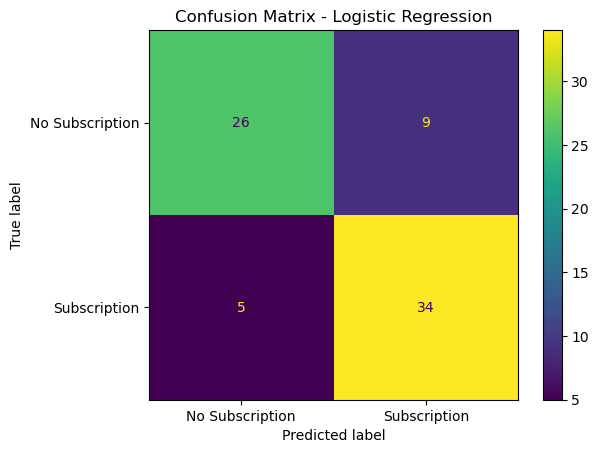

In [36]:
display_cm = ConfusionMatrixDisplay(  # Create a confusion matrix display object
    confusion_matrix=cm_logistic,  # Use the confusion matrix created above
    display_labels=["No Subscription", "Subscription"]  # Add class labels for easier interpretation
)  # End of ConfusionMatrixDisplay

display_cm.plot()  # Plot the confusion matrix

plt.title("Confusion Matrix - Logistic Regression")  # Add a title to the plot

plt.show()

## Understanding the Logistic Confusion Matrix:
- **No Subscription:** means the customers did not subscribe to the investment product.
- **Subscription:** means the customers subscribed to the investment product.

The confusion matrix helps us see:

- How many customers were correctly predicted as not subscribing 
- How many customers were correctly predicted as subscribing  
- How many customers were incorrectly predicted as subscribing  
- How many customers were incorrectly predicted as not subscribing

In [57]:
# Display a full classification report
# This includes precision, recall, F1-score, and support for each class

print("Classification Report:")
print(classification_report(y_test, y_pred_logistic, target_names=["No Subscription", "Subscription"], zero_division=0))

Classification Report:
                 precision    recall  f1-score   support

No Subscription       0.84      0.74      0.79        35
   Subscription       0.79      0.87      0.83        39

       accuracy                           0.81        74
      macro avg       0.81      0.81      0.81        74
   weighted avg       0.81      0.81      0.81        74



# Step 9: Building SVM as a Comparison Model

In this step, we use SVM, which stands for Support Vector Machine.

SVM is another supervised machine learning algorithm used for classification.

We use SVM as a comparison model.

This means we want to compare its performance with Logistic Regression.

To make the comparison fair, we use the same:

- Training data 
- Testing data 
- Preprocessed features 
- Target variable 

The goal is to see which model performs better on this dataset.

In [37]:
# Import Support Vector Classifier from scikit-learn 

from sklearn.svm import SVC  

In [38]:
svm_model = SVC(random_state=42)  # Create an SVM classification model

In [42]:
svm_model.fit(X_train_processed, y_train)  # Train the SVM model using the preprocessed training data

print("SVM model trained successfully!")  # Print a success message after training

SVM model trained successfully!


In [44]:
y_pred_svm = svm_model.predict(X_test_processed)  # Use the trained SVM model to predict values for the test data

print("SVM predictions completed successfully!")  # Print a success message after prediction

SVM predictions completed successfully!


In [45]:
# Display the predicted values
# 0 means the customer is predicted not to subscribe
# 1 means the customer is predicted to subscribe

print("Predicted SVM values:")
print(y_pred_svm)

Predicted SVM values:
[1 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1]


In [46]:
svm_comparison_df = pd.DataFrame({  # Create a DataFrame to compare actual and predicted values
    "Actual": y_test.values,  # Add the real target values from the test set
    "SVM_Predicted": y_pred_svm  # Add the predicted values from the SVM model
})  # End of DataFrame creation

display(svm_comparison_df.head(10))  # Display the first 10 actual and predicted values

,Actual,SVM_Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,0,0
6,1,1
7,1,1
8,1,1
9,0,0


## In this step, we trained an SVM model.

SVM is used as a comparison model.

We trained it using the same preprocessed training data that we used for Logistic Regression.

Then, we used the SVM model to make predictions on the test data.

The next step is to evaluate the SVM model and compare it with Logistic Regression.

# Step 10: Evaluating SVM Model

After training the SVM model, we need to evaluate its performance.

We will calculate:

- Accuracy 
- Precision 
- Recall 
- F1-score 
- Confusion Matrix 

Then, we will compare the SVM model with the Logistic Regression model.

This comparison helps us understand which model performs better on this dataset.

A model comparison is important because different algorithms may behave differently on the same data.

In [53]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate the accuracy of the SVM model

precision_svm = precision_score(y_test, y_pred_svm)  # Calculate the precision of the SVM model

recall_svm = recall_score(y_test, y_pred_svm)  # Calculate the recall of the SVM model

f1_svm = f1_score(y_test, y_pred_svm)  # Calculate the F1-score of the SVM model

print("SVM Evaluation Metrics:")  # Print a title for SVM evaluation metrics

print("Accuracy:", accuracy_svm)  # Print the SVM accuracy score

print("Precision:", precision_svm)  # Print the SVM precision score

print("Recall:", recall_svm)  # Print the SVM recall score

print("F1-score:", f1_svm)  # Print the SVM F1-score

SVM Evaluation Metrics:
Accuracy: 0.7972972972972973
Precision: 0.7727272727272727
Recall: 0.8717948717948718
F1-score: 0.8192771084337349


In [54]:
cm_svm = confusion_matrix(y_test, y_pred_svm)  # Create the confusion matrix for the SVM model

print("Confusion Matrix - SVM:")  # Print a title for the SVM confusion matrix

print(cm_svm)  # Display the SVM confusion matrix as numbers

Confusion Matrix - SVM:
[[25 10]
 [ 5 34]]


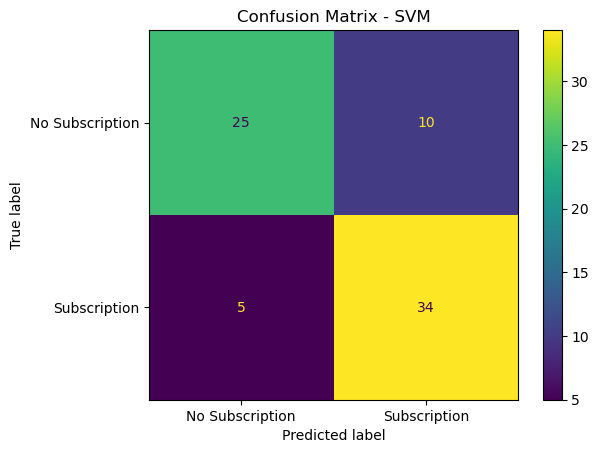

In [55]:
display_cm_svm = ConfusionMatrixDisplay(  # Create a display object for the SVM confusion matrix
    confusion_matrix=cm_svm,  # Use the SVM confusion matrix created above
    display_labels=["No Subscription", "Subscription"]  # Add class labels for easier interpretation
)  # End of ConfusionMatrixDisplay

display_cm_svm.plot()  # Plot the SVM confusion matrix

plt.title("Confusion Matrix - SVM")  # Add a title to the plot

plt.show()

## Understanding the SVM Confusion Matrix:

The confusion matrix shows how many predictions were correct and incorrect.

The confusion matrix helps us see:

- How many customers were correctly predicted as not subscribing 
- How many customers were correctly predicted as subscribing  
- How many customers were incorrectly predicted as subscribing  
- How many customers were incorrectly predicted as not subscribing

In [56]:
# Display a full classification report
# This includes precision, recall, F1-score, and support for each class

print("Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm, target_names=["No Subscription", "Subscription"], zero_division=0))

Classification Report - SVM:
                 precision    recall  f1-score   support

No Subscription       0.83      0.71      0.77        35
   Subscription       0.77      0.87      0.82        39

       accuracy                           0.80        74
      macro avg       0.80      0.79      0.79        74
   weighted avg       0.80      0.80      0.80        74



# Step 11: Comparing the SVM Model with Logistic Regression Model

In [58]:
from sklearn.metrics import accuracy_score  # Import accuracy metric

from sklearn.metrics import precision_score  # Import precision metric

from sklearn.metrics import recall_score  # Import recall metric

from sklearn.metrics import f1_score  # Import F1-score metric

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)  # Calculate accuracy for Logistic Regression

precision_logistic = precision_score(y_test, y_pred_logistic)  # Calculate precision for Logistic Regression

recall_logistic = recall_score(y_test, y_pred_logistic)  # Calculate recall for Logistic Regression

f1_logistic = f1_score(y_test, y_pred_logistic)  # Calculate F1-score for Logistic Regression

accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate accuracy for SVM

precision_svm = precision_score(y_test, y_pred_svm)  # Calculate precision for SVM

recall_svm = recall_score(y_test, y_pred_svm)  # Calculate recall for SVM

f1_svm = f1_score(y_test, y_pred_svm)  # Calculate F1-score for SVM

print("All evaluation metrics were calculated successfully.")  # Print success message

All evaluation metrics were calculated successfully.


In [59]:
model_comparison_df = pd.DataFrame({  # Create a DataFrame to compare both models
    "Model": ["Logistic Regression", "SVM"],  # Add model names
    "Accuracy": [accuracy_logistic, accuracy_svm],  # Add accuracy scores
    "Precision": [precision_logistic, precision_svm],  # Add precision scores
    "Recall": [recall_logistic, recall_svm],  # Add recall scores
    "F1-score": [f1_logistic, f1_svm]  # Add F1-scores
})  # End of comparison DataFrame

display(model_comparison_df)  # Display the model comparison table

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.810811,0.790698,0.871795,0.829268
1,SVM,0.797297,0.772727,0.871795,0.819277


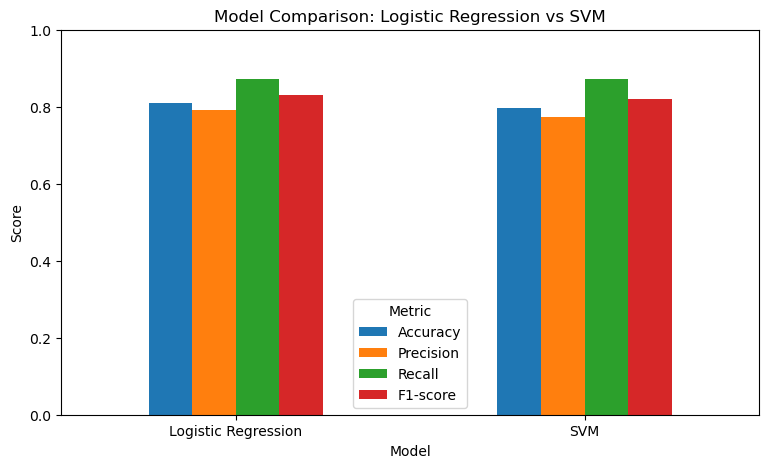

In [60]:
model_comparison_df.set_index("Model").plot(kind="bar", figsize=(9, 5))  # Create a bar chart to compare model metrics

plt.title("Model Comparison: Logistic Regression vs SVM")  # Add chart title

plt.xlabel("Model")  # Add x-axis label

plt.ylabel("Score")  # Add y-axis label

plt.ylim(0, 1)  # Set y-axis range from 0 to 1

plt.xticks(rotation=0)  # Keep model names horizontal

plt.legend(title="Metric")  # Add legend title

plt.show()  # Display the chart

# Step 12: Interpreting Classification Outputs
After evaluating the models, we need to understand the meaning of the classification outputs.

A classification model can give us two important outputs:

- Predicted class
- Predicted probability

In this dataset:
- 0 means the customer is predicted as No Subscription.
- 1 means the customer is predicted as a Subscription.
  
For Logistic Regression, the model can also estimate the probability of each class.

In [63]:
y_prob_logistic = logistic_model.predict_proba(X_test_processed)  # Get predicted probabilities from the Logistic Regression model

prob_no_subscription = y_prob_logistic[:, 0]  # Store the probability of class 0, which means No Subscription

prob_subscription = y_prob_logistic[:, 1]  # Store the probability of class 1, which means Subscription

print("Predicted probabilities created successfully.")  # Print a success message

Predicted probabilities created successfully.


In [64]:
classification_output_df = pd.DataFrame({  # Create a DataFrame to show actual values, predictions, and probabilities
    "Actual": y_test.values,  # Add the actual target values
    "Predicted": y_pred_logistic,  # Add the predicted class values
    "Probability_No_Subscription": prob_no_subscription.round(3),  # Add rounded probability for No Subscription
    "Probability_Subscription": prob_subscription.round(3)  # Add rounded probability for Subscription
})  # End of DataFrame creation

display(classification_output_df.head(15))  # Display the first 15 rows of the classification output table

,Actual,Predicted,Probability_No_Subscription,Probability_Subscription
0,1,1,0.002,0.998
1,0,0,0.735,0.265
2,1,1,0.013,0.987
3,0,0,0.977,0.023
4,1,1,0.087,0.913
5,0,0,0.870,0.130
6,1,1,0.111,0.889
7,1,1,0.086,0.914
8,1,1,0.450,0.550
9,0,1,0.445,0.555


In [65]:
classification_output_df["Actual_Label"] = classification_output_df["Actual"].map({0: "No Subscription", 1: "Subscription"})  # Convert actual numbers to readable labels

classification_output_df["Predicted_Label"] = classification_output_df["Predicted"].map({0: "No Subscription", 1: "Subscription"})  # Convert predicted numbers to readable labels

display(classification_output_df.head(15))  # Display the updated table with readable labels

,Actual,Predicted,Probability_No_Subscription,Probability_Subscription,Actual_Label,Predicted_Label
0,1,1,0.002,0.998,Subscription,Subscription
1,0,0,0.735,0.265,No Subscription,No Subscription
2,1,1,0.013,0.987,Subscription,Subscription
3,0,0,0.977,0.023,No Subscription,No Subscription
4,1,1,0.087,0.913,Subscription,Subscription
5,0,0,0.870,0.130,No Subscription,No Subscription
6,1,1,0.111,0.889,Subscription,Subscription
7,1,1,0.086,0.914,Subscription,Subscription
8,1,1,0.450,0.550,Subscription,Subscription
9,0,1,0.445,0.555,No Subscription,Subscription


In [66]:
classification_output_df["Decision_Explanation"] = classification_output_df["Probability_Subscription"].apply(  # Create an explanation for each prediction
    lambda p: "Predicted Subscription because probability is 0.50 or higher" if p >= 0.50 else "Predicted No Subscription because probability is below 0.50"  # Explain the prediction based on the threshold
)  # End of apply function

display(classification_output_df.head(15))  # Display the table with decision explanations

,Actual,Predicted,Probability_No_Subscription,Probability_Subscription,Actual_Label,Predicted_Label,Decision_Explanation
0,1,1,0.002,0.998,Subscription,Subscription,Predicted Subscription because probability is ...
1,0,0,0.735,0.265,No Subscription,No Subscription,Predicted No Subscription because probability ...
2,1,1,0.013,0.987,Subscription,Subscription,Predicted Subscription because probability is ...
3,0,0,0.977,0.023,No Subscription,No Subscription,Predicted No Subscription because probability ...
4,1,1,0.087,0.913,Subscription,Subscription,Predicted Subscription because probability is ...
5,0,0,0.870,0.130,No Subscription,No Subscription,Predicted No Subscription because probability ...
6,1,1,0.111,0.889,Subscription,Subscription,Predicted Subscription because probability is ...
7,1,1,0.086,0.914,Subscription,Subscription,Predicted Subscription because probability is ...
8,1,1,0.450,0.550,Subscription,Subscription,Predicted Subscription because probability is ...
9,0,1,0.445,0.555,No Subscription,Subscription,Predicted Subscription because probability is ...


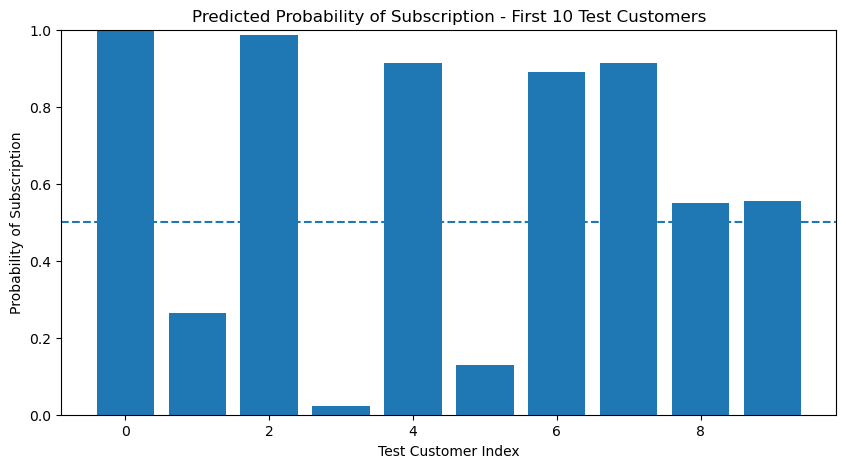

In [67]:
first_10_outputs = classification_output_df.head(10)  # Select the first 10 rows for a simple visualization

plt.figure(figsize=(10, 5))  # Create a figure with a suitable size

plt.bar(first_10_outputs.index, first_10_outputs["Probability_Subscription"])  # Create a bar chart for subscription probabilities

plt.axhline(y=0.50, linestyle="--")  # Add a threshold line at 0.50

plt.ylim(0, 1)  # Set the y-axis range from 0 to 1

plt.title("Predicted Probability of Subscription - First 10 Test Customers")  # Add a chart title

plt.xlabel("Test Customer Index")  # Add x-axis label

plt.ylabel("Probability of Subscription")  # Add y-axis label

plt.show()  # Display the chart

# Interpreting the Probability Chart
The chart shows the predicted probability of subscription for the first 10 test customers.

The dashed line shows the threshold of 0.50.

If the probability of subscription is 0.50 or higher, the model predicts:

- Subscription = 1

If the probability of subscription is below 0.50, the model predicts:

- No Subscription = 0

This helps us understand that classification models do not only give a final class.
They can also show how confident the model is about each prediction.

However, the probability should be interpreted carefully.
A high probability does not mean the prediction is always correct.

# Task 2: Compare the results and interpret them

Write a short explanation answering:

- Which model performed better? 
- Which metric is most important for your business problem? 
- What do false positives and false negatives mean in your dataset? 
- What is one possible limitation or bias in your model? 
- Why should human judgment still be used?

# Final Interpretation and Business Conclusion

After training, evaluating, and comparing the models, we need to interpret the results.

In machine learning, the final goal is not only to build a model.

The final goal is to understand what the model results mean and how they can support decision-making.

In this project, we compared two models:
- Logistic Regression 
- SVM 

We evaluated them using:
- Accuracy 
- Precision 
- Recall 
- F1-score 

Based on the model comparison, we can decide which model performed better on this dataset.

In [68]:
print("Final Model Comparison Table:")  # Print a title for the final comparison table

display(model_comparison_df)  # Display the comparison table for Logistic Regression and SVM

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.810811,0.790698,0.871795,0.829268
1,SVM,0.797297,0.772727,0.871795,0.819277


In [69]:
best_model_row = model_comparison_df.loc[model_comparison_df["F1-score"].idxmax()]  # Find the row with the highest F1-score

best_model_name = best_model_row["Model"]  # Store the name of the best model

best_f1_score = best_model_row["F1-score"]  # Store the best F1-score value

print("Best model based on F1-score:")  # Print a title for the best model

print(best_model_name)  # Print the name of the best model

print("\nBest F1-score:")  # Print a title for the best F1-score

print(best_f1_score)  # Print the best F1-score value

Best model based on F1-score:
Logistic Regression

Best F1-score:
0.8292682926829268


In [70]:
print("Final Conclusion:")  # Print a title for the final conclusion

print(f"Based on the F1-score, the better model for this dataset is {best_model_name}.")  # Print the best model based on F1-score

print("This model gives the best balance between precision and recall.")  # Explain why F1-score is useful

print("However, the final model choice should also depend on the business goal.")  # Explain that business context matters

Final Conclusion:
Based on the F1-score, the better model for this dataset is Logistic Regression.
This model gives the best balance between precision and recall.
However, the final model choice should also depend on the business goal.


# Short Explanation:

### 1. Which model performed better?
Based on the F1-score from your notebook's output. The final step identified logistic regression as the best model. 
This means it achieved a better balance between precision and recall than SVM when predicting which customers would subscribe to the investment product.

### 2. Which metric is most important for your business problem?
Recall is the most important metric here, with F1-score used as the deciding comparison metric.

The bank's goal is to identify customers likely to subscribe to an investment product to improve marketing targeting. Missing a potential subscriber (a false negative) is costly; the bank loses a revenue opportunity entirely. 
A slightly lower precision (contacting some customers who won't subscribe) is far less costly a mistake than overlooking someone who would have subscribed. 

Recall measures exactly how many actual subscribers the model successfully catches, making it the priority metric. The F1-score is useful as a balancing measure between precision and recall.

### 3. What do false positives and false negatives mean in your dataset?
| Error Type | What It Means | Business Impact |
|---|---|---|
| **False Positive** | The model predicts a customer will subscribe, but they actually won't | The bank wastes marketing resources (calls, emails, ads) on an uninterested customer |
| **False Negative** | The model predicts a customer won't subscribe, but they actually would have | The bank misses a real sales opportunity, a willing customer is never contacted |

In this context, **false negatives are more damaging** because they represent lost revenue and missed customer engagement opportunities.

### 4. What is one possible limitation or bias in your model?
One possible limitation is **class imbalance bias**. 

In real-world bank marketing data, the number of customers who don't subscribe typically far outnumbers those who do. If the dataset is imbalanced, both models may be biased toward predicting "No Subscription" more often, which inflates accuracy while underperforming on the minority class (actual subscribers). The notebook fills missing values with median/mode and splits data with stratify=y, which helps, but it does not apply any resampling techniques (like SMOTE or class weighting) to correct for imbalance. This means the model may still underperform at identifying the customers the bank cares most about.


### 5. Why should human judgment still be used?
Even if the model performs well on test data, human judgment remains essential for several reasons:

- **Context the model can't see:** A model trained on historical data cannot account for real-time factors like a customer recently losing their job, a market downturn, or a personal conversation a banker already had with them.

- **Ethical and fairness concerns:** Automated decisions about who to target for financial products can inadvertently reflect historical biases (e.g., discriminating by age or employment status). A human reviewer can catch unfair patterns.

- **High-stakes decisions:** Targeting or excluding a customer for a financial product has real consequences. A human should validate edge cases where the model's confidence is low.

- **Model drift:** Customer behavior changes over time. A model trained on past data may become stale. A human needs to monitor performance and decide when to retrain.

- **Regulatory compliance:** In financial services, banks are often required to explain and justify customer-facing decisions, which a black-box model alone cannot fully satisfy.

In short, the model is a powerful decision-support tool, but it should inform human decisions not replace them.


### In this step, we will prepare the important output files and organize the project.

In [71]:
from pathlib import Path  # Import Path to work with folders and file paths

output_folder = Path("outputs")  # Create a folder name for saving output files

output_folder.mkdir(exist_ok=True)  # Create the folder if it does not already exist

print("Output folder is ready.")  # Print a success message

Output folder is ready.


In [72]:
cleaned_data_path = output_folder / "cleaned_investment_product_subscription_dataset.xls"  # Define the file path for the cleaned dataset

df_clean.to_csv(cleaned_data_path, index=False)  # Save the cleaned dataset as a CSV file

print("Cleaned dataset saved successfully.")  # Print a success message

print(cleaned_data_path)  # Print the saved file path

Cleaned dataset saved successfully.
outputs\cleaned_investment_product_subscription_dataset.xls


In [73]:
model_results_path = output_folder / "model_comparison_results.csv"  # Define the file path for model comparison results

model_comparison_df.to_csv(model_results_path, index=False)  # Save the model comparison table as a CSV file

print("Model comparison results saved successfully.")  # Print a success message

print(model_results_path)  # Print the saved file path

Model comparison results saved successfully.
outputs\model_comparison_results.csv


In [74]:
classification_output_path = output_folder / "classification_outputs.csv"  # Define the file path for classification outputs

classification_output_df.to_csv(classification_output_path, index=False)  # Save actual values, predictions, and probabilities as a CSV file

print("Classification outputs saved successfully.")  # Print a success message

print(classification_output_path)  # Print the saved file path

Classification outputs saved successfully.
outputs\classification_outputs.csv
